In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [2]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 5.1' / 'summary.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    # print(data)

C:\Users\whamp\PycharmProjects\research_project


In [3]:
# aim is to plot the mode energies and separation against: period, thickness, filling

df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])

count_length_not_2 = 0
count_not_correct_form = 0
count_correct_form = 0
count_correct_vertices = 0
total = 0

# print(data)

# Extract data
for key, value in data.items():
    total += 1
    #print(value)
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    ff = float(key_parts[2].split('=')[1].replace('nm', ''))
    
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        count_length_not_2 += 1
        continue
    
   

    temp_vertices:list = []
    
    # Only consider entries with R2 > 0.6
    for i,key1 in enumerate(keys):
        R2 = value['fitting info'][key1]['R2']
        if (abs(R2) > 0.6) and (abs(R2) != 1.0):
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append([key1,vertex])
            #print([key1,vertex])
            
    if len(temp_vertices) == 2:
        vtc1 = int(temp_vertices[0][0])
        vtc2 = int(temp_vertices[1][0])
        
        if (vtc1 % 2) > (vtc2 % 2):
            # if the first one is odd and second is even, ensure first vertex energy higher. + vice versa.
            if temp_vertices[0][1] < temp_vertices[1][1]:
                # select where 1st vertex value less than second
                vtcs: list = [vtc1, vtc2]
                # print(key)
                # print(value)
                count_correct_vertices += 1
                
                vertices = [temp_vertices[0][1], temp_vertices[1][1]]
        
                mean_energy_value = np.mean(vertices)
                diff_energy_value = vertices[1] - vertices[0]
                    
                new_row = {
                    'period': period,
                    'thickness': thickness,
                    'filling': ff,
                    'mean_energy': mean_energy_value,
                    'diff_energy': diff_energy_value
                }
                
                # Append the new row to the DataFrame
                df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
        
        elif (vtc1 % 2) < (vtc2 % 2):
            count_correct_form += 1
            # eg 0 3 or 0 5
            if temp_vertices[0][1] > temp_vertices[1][1]:
                # select where 1st vertex value greater than second
                vtcs: list = [vtc1, vtc2]
                # print(key)
                # print(value)
                count_correct_vertices += 1
                
                vertices = [temp_vertices[0][1], temp_vertices[1][1]]
        
                mean_energy_value = np.mean(vertices)
                diff_energy_value = vertices[1] - vertices[0]
                    
                new_row = {
                    'period': period,
                    'thickness': thickness,
                    'filling': ff,
                    'mean_energy': mean_energy_value,
                    'diff_energy': diff_energy_value
                }
                
                # Append the new row to the DataFrame
                df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
            
        else:
            count_not_correct_form += 1
            continue
            
    else:
        count_length_not_2 += 1
        continue

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   period       49 non-null     float64
 1   thickness    49 non-null     float64
 2   filling      49 non-null     float64
 3   mean_energy  49 non-null     float64
 4   diff_energy  49 non-null     float64
dtypes: float64(5)
memory usage: 2.0 KB


C:\Users\whamp\AppData\Local\Temp\ipykernel_17712\386674686.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [4]:
counts = pd.Series([count_length_not_2, count_not_correct_form, count_correct_form, count_correct_vertices, total], index=['len not 2', 'not correct form', 'correct form', 'correct vertices', 'total'])
counts

len not 2            57
not correct form      1
correct form         56
correct vertices     49
total               197
dtype: int64

In [5]:

# # title = 'Mode separation energy as function of thickness'
# 
# # Lists to store filtered data
# df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])
# 
# for key, value in data.items():
#     # Extract thickness (t) and period (Λ) from the key string
#     key_parts = key.split()
#     thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
#     period = float(key_parts[1].split('=')[1].replace('nm', ''))
#     ff = float(key_parts[2].split('=')[1].replace('nm', ''))
#     
#     keys = list(value['fitting info'].keys())
# 
#     if len(keys) < 2:
#         continue
#     
#     temp_vertices = []
# 
#     temp_period = float(period)
#     temp_thickness = float(thickness)
#     temp_filling = float(ff)
#     
#     # Only consider entries with R2 > 0.6
#     for i, key1 in enumerate(keys):
#         R2 = value['fitting info'][key1]['R2']
#         if abs(R2) > 0.6:
#             # Extract vertex value from fitting results
#             vertex = value['fitting results']['vertices'][i]
#             
#             # Append data to temporary list
#             temp_vertices.append(vertex)
# 
#     if len(temp_vertices) == 2:
#         
#         if temp_vertices[0] > temp_vertices[1]:
#             # select where 1st vertex value greater than second
#             count_correct_form += 1
#             
#         else:
#             count_not_correct_form += 1
#             continue
#             
#         mean_energy_value = np.mean(temp_vertices)
#         diff_energy_value = np.diff(temp_vertices)[0]
#         
#         # Create a new row as a dictionary
#         new_row = {
#             'period': temp_period,
#             'thickness': temp_thickness,
#             'filling': temp_filling,
#             'mean_energy': mean_energy_value,
#             'diff_energy': diff_energy_value
#         }
#         
#         # Append the new row to the DataFrame
#         df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
# 
# # df['diff_energy']=df['diff_energy'].apply(np.abs)
# 
# # Convert DataFrame columns to numpy arrays

periods = df['period'].to_numpy()
thicknesses = df['thickness'].to_numpy()
filling = df['filling'].to_numpy()
diff_energy = df['diff_energy'].to_numpy()
mean_energy = df['mean_energy'].to_numpy()

# 
# df.head(5)
# df.info()


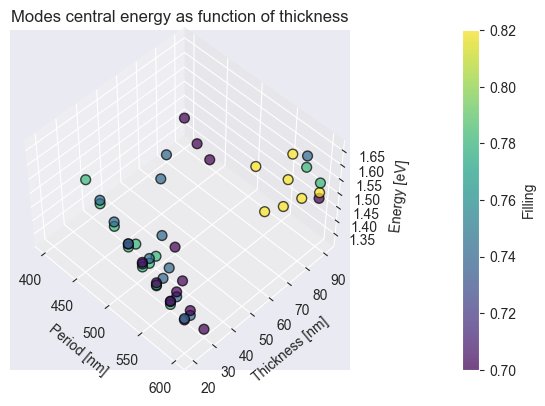

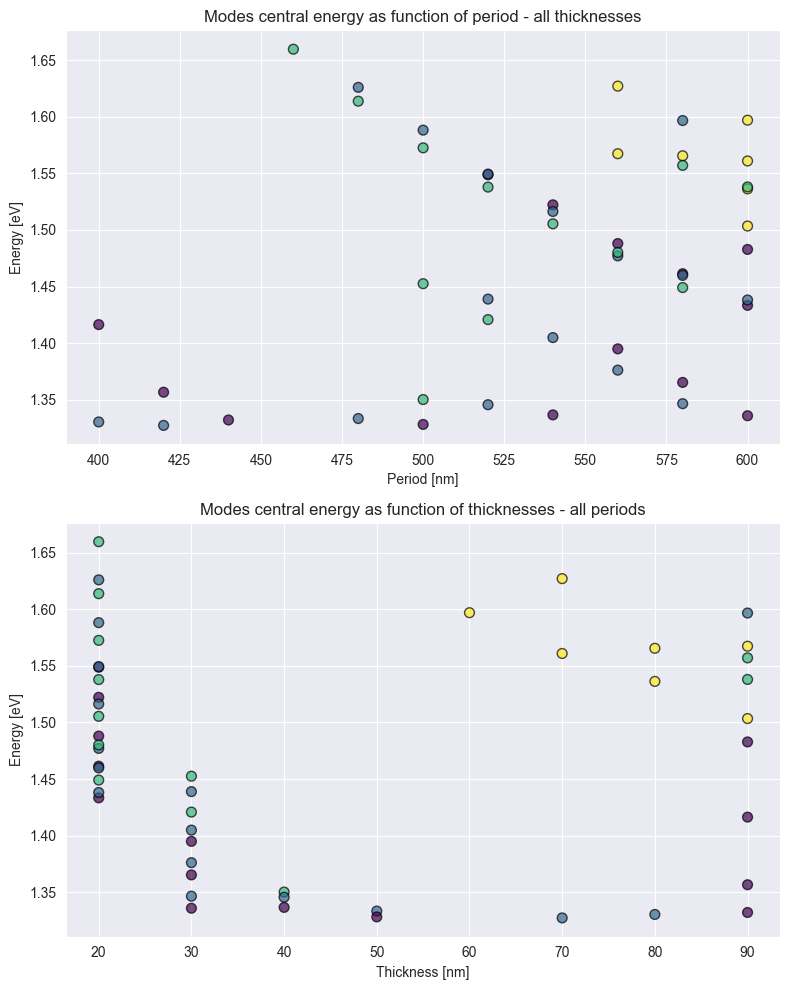

In [6]:
title = 'Modes central energy as function of thickness'

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes central energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes central energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

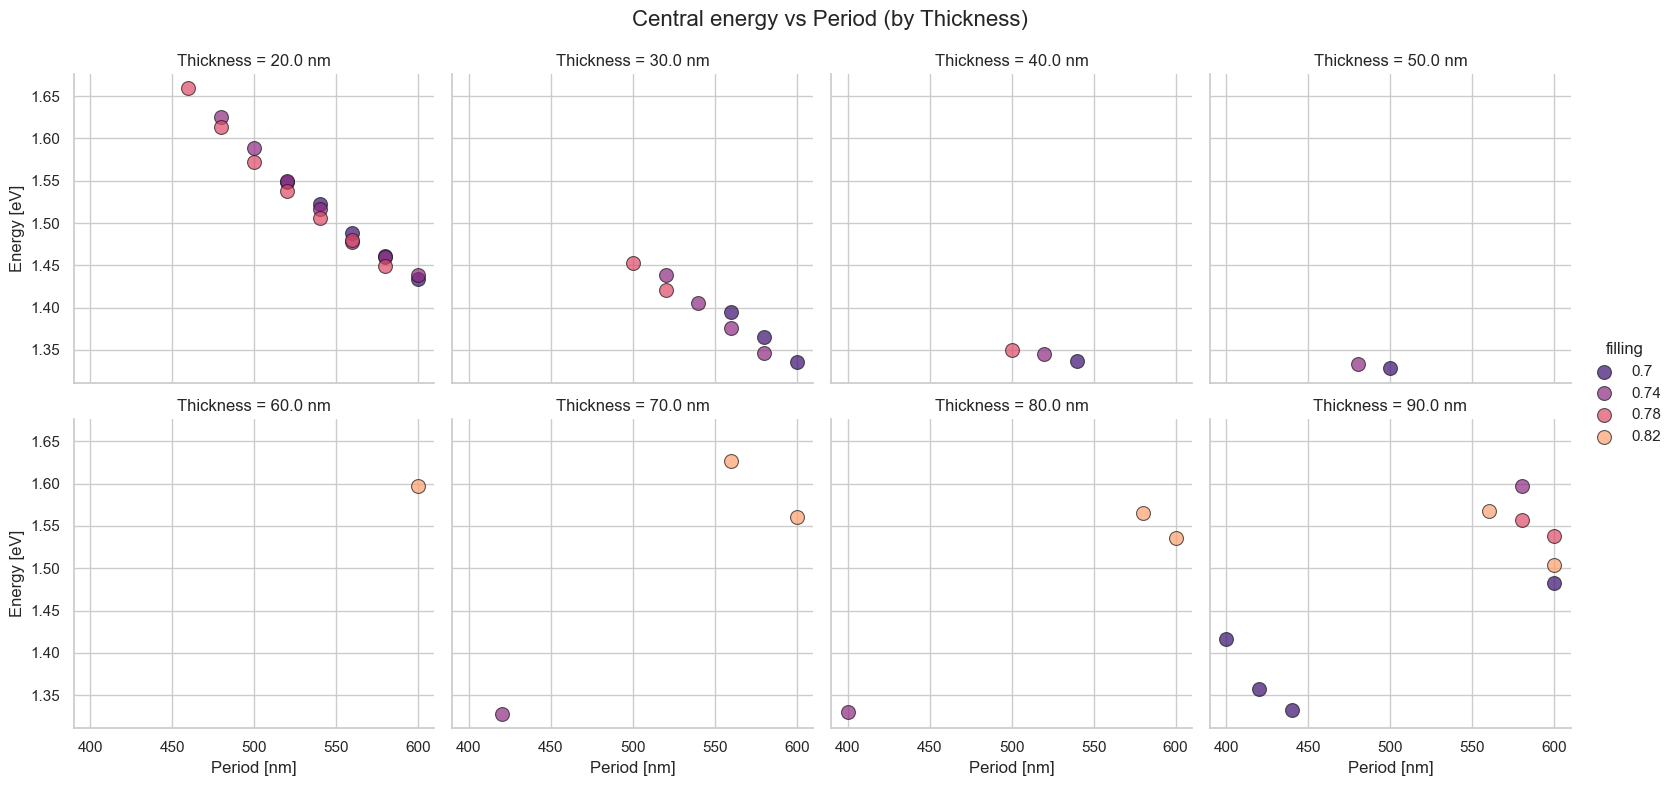

<Figure size 1500x1000 with 0 Axes>

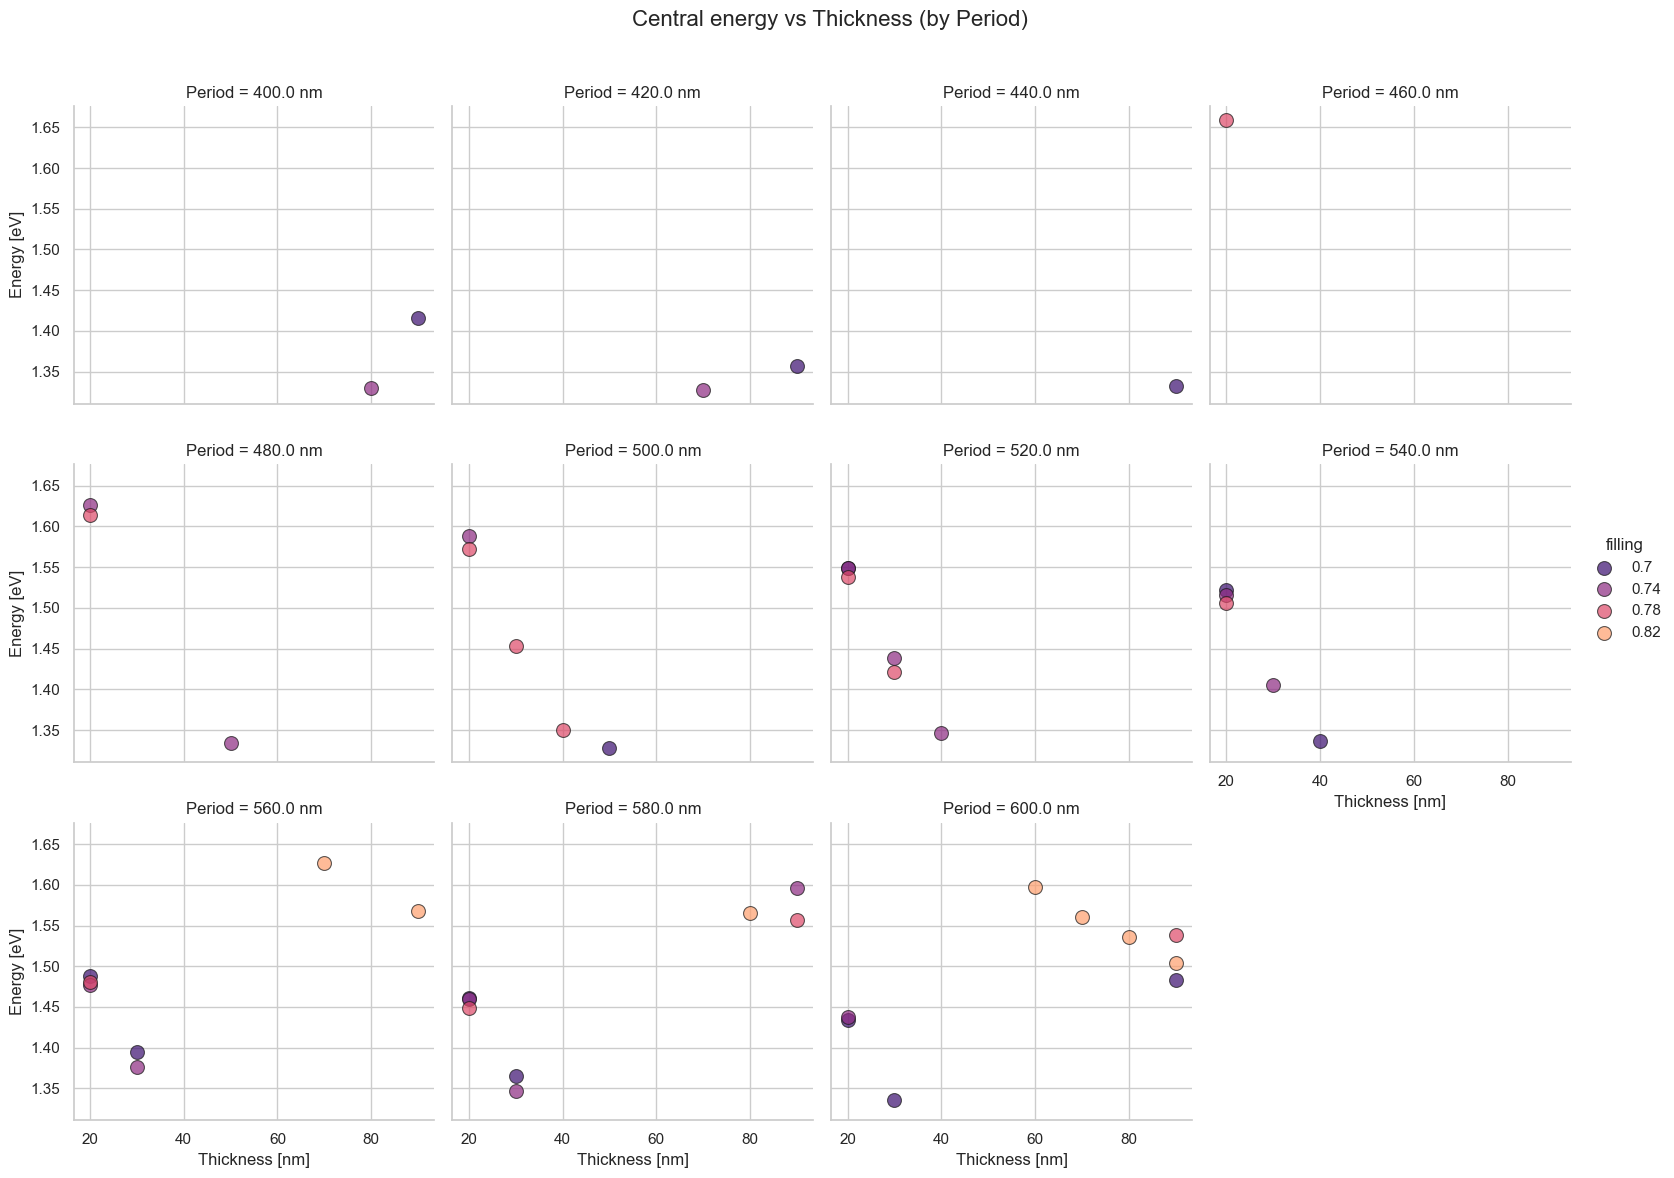

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=4, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Central energy vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=4, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Central energy vs Thickness (by Period)', fontsize=16)
plt.show()


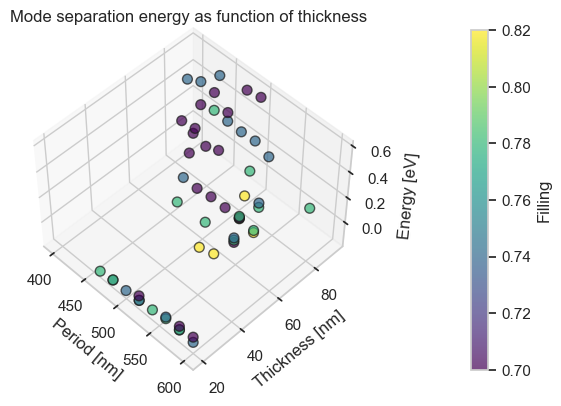

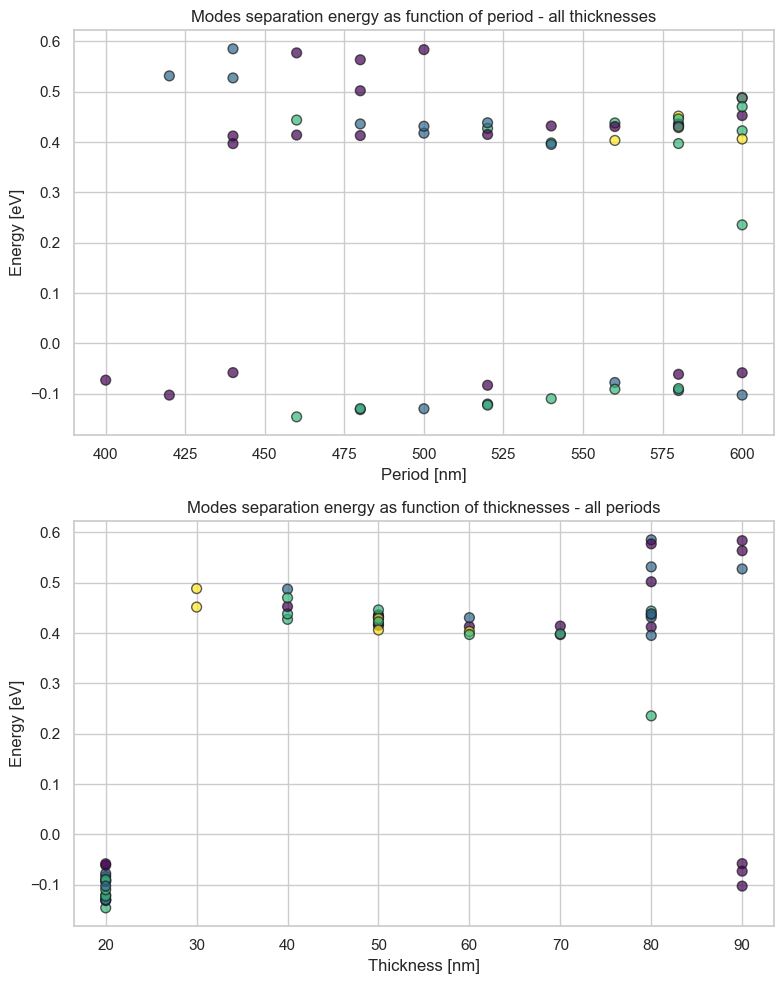

In [37]:

title = 'Mode separation energy as function of thickness'
#  = 'Modes central energy as function of thickness'


fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes separation energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes separation energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

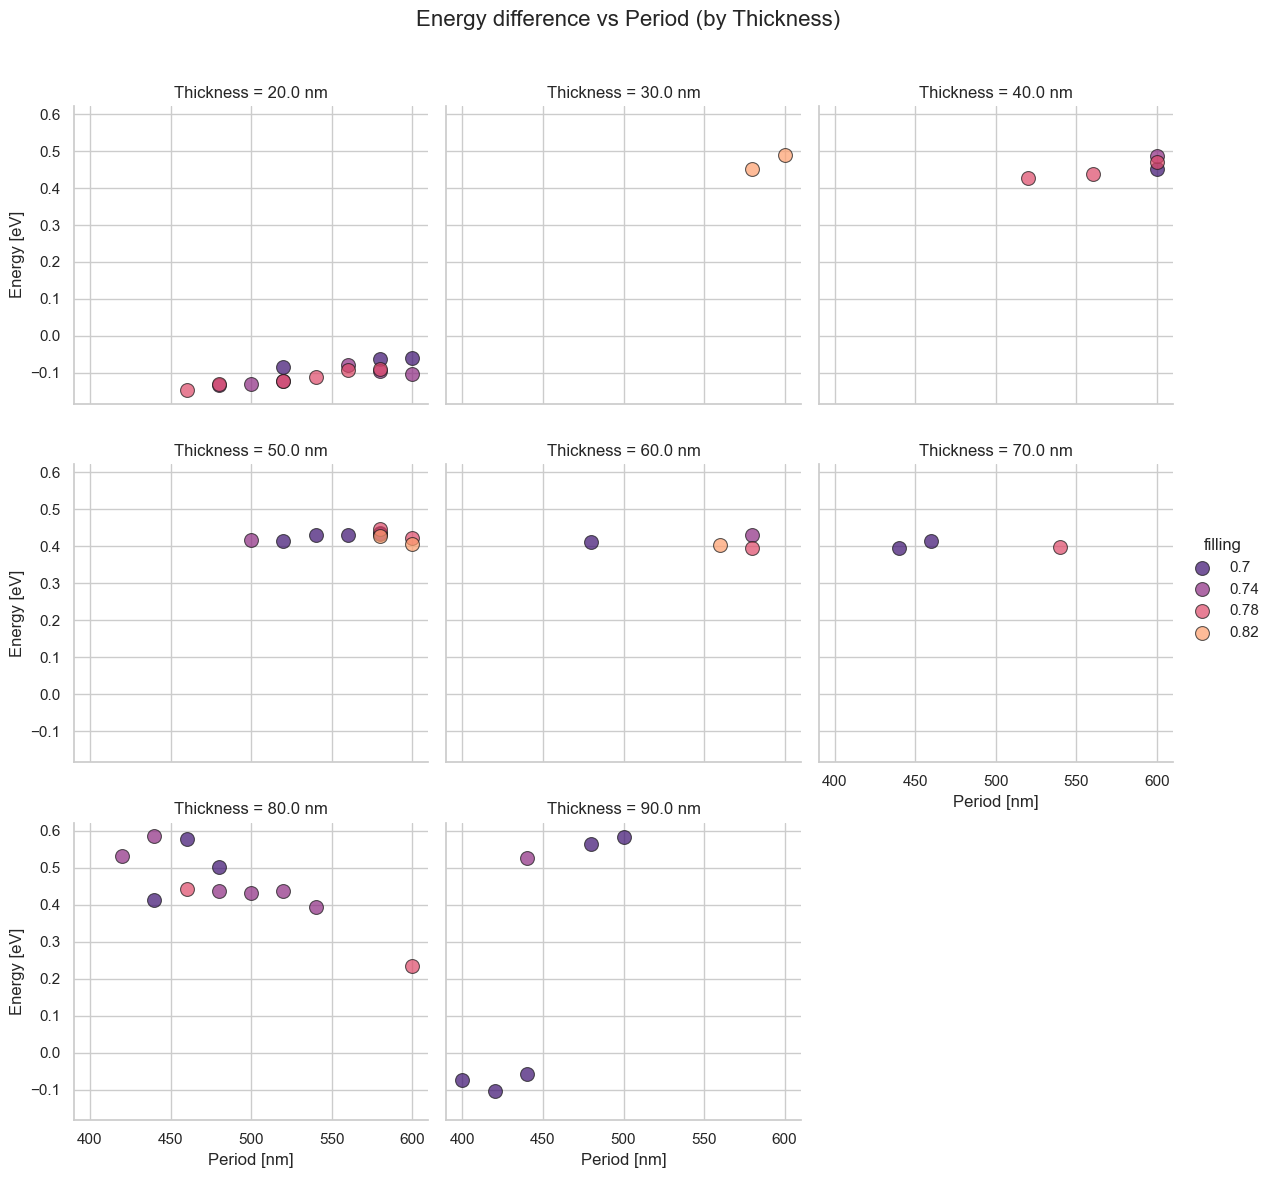

<Figure size 1500x1000 with 0 Axes>

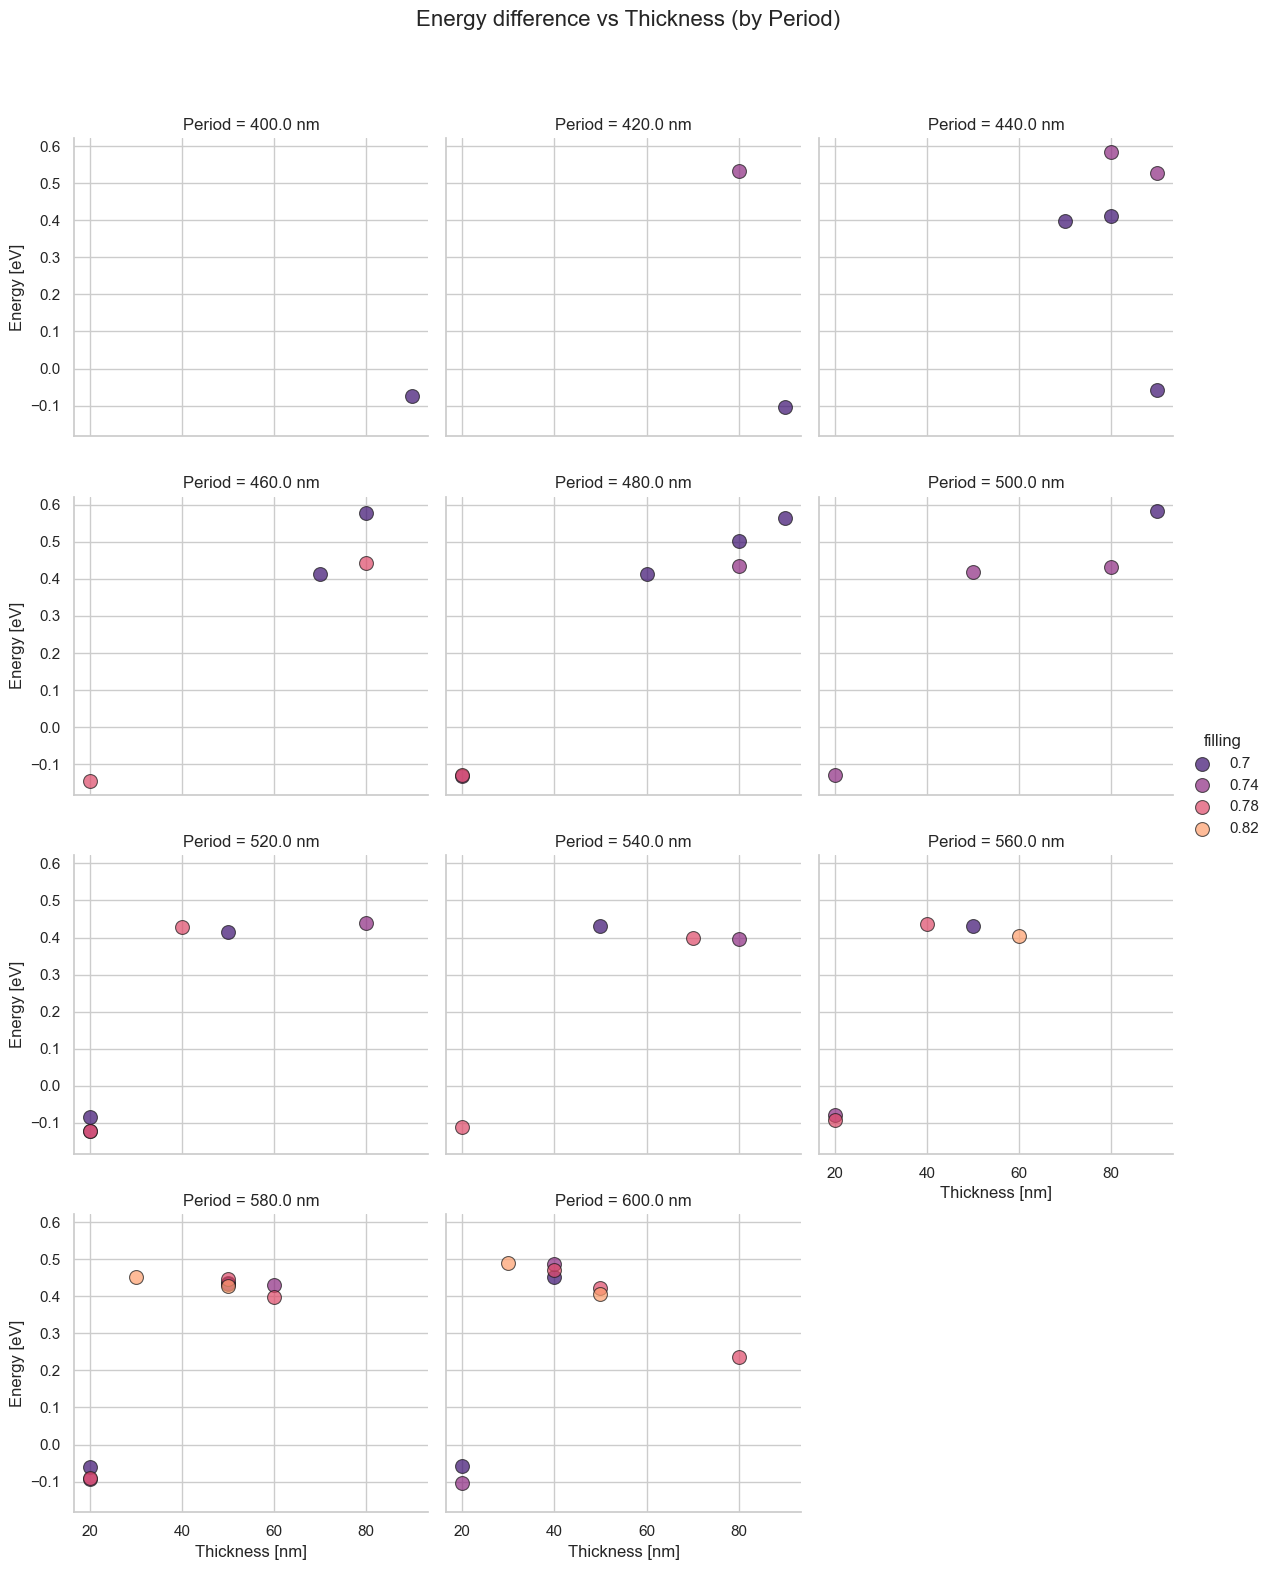

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Energy difference vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Energy difference vs Thickness (by Period)', fontsize=16)
plt.show()


In [41]:
print()